# 01 - Data exploration

Exploration of the PhiUSIIL URL dataset (`url`, `label`; **1 = phishing, 0 = legitimate**).

> **Safety:** URLs are treated strictly as text. Nothing here visits, fetches or resolves them. `tldextract` is configured to use its bundled suffix list (no network).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tldextract
from urllib.parse import urlsplit

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

df = pd.read_csv("../data/raw/phiusiil_urls.csv")
df["cls"] = df["label"].map({1: "phishing", 0: "legitimate"})
print(df.shape)
df.head()

(235795, 3)


,url,label,cls
0,https://www.southbankmosaics.com,0,legitimate
1,https://www.uni-mainz.de,0,legitimate
2,https://www.voicefmradio.co.uk,0,legitimate
3,https://www.sfnmjournal.com,0,legitimate
4,https://www.rewildingargentina.org,0,legitimate


## 1. Class balance
How many URLs per class, and whether the dataset is imbalanced.

In [2]:
counts = df["cls"].value_counts()
pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(2)})

,count,percent
cls,,
legitimate,134850,57.19
phishing,100945,42.81


## 2. Duplicate URLs
Exact duplicate URL strings (overall, and whether any URL appears with *both* labels, which would be label noise / leakage).

In [3]:
print("Duplicate rows (url repeated, keeping first):", df["url"].duplicated().sum())
print("Duplicates per class:")
print(df[df["url"].duplicated()]["cls"].value_counts())
conflict = df.groupby("url")["label"].nunique()
print("URLs with conflicting labels:", (conflict > 1).sum())

Duplicate rows (url repeated, keeping first): 425
Duplicates per class:
cls
phishing    425
Name: count, dtype: int64


URLs with conflicting labels: 0


## 3. Homepage-only URLs
Share of URLs per class with no path (or just `/`), no query string and no fragment, e.g. `https://example.com/`. If one class is almost all homepages, path/query features alone would separate the classes trivially.

In [4]:
def is_homepage(u):
    p = urlsplit(u)
    return p.path in ("", "/") and not p.query and not p.fragment

df["homepage"] = df["url"].map(is_homepage)
(df.groupby("cls")["homepage"].mean() * 100).round(2).rename("% homepage-only").to_frame()

,% homepage-only
cls,
legitimate,100.0
phishing,71.6


## 4. HTTPS usage
Share of URLs per class starting with `https://`. A large gap here is a strong, possibly dataset-specific, signal.

In [5]:
df["https"] = df["url"].str.lower().str.startswith("https://")
print((df.groupby("cls")["https"].mean() * 100).round(2).rename("% https").to_frame())
print()
print("Scheme breakdown:")
df["scheme"] = df["url"].str.extract(r"^([A-Za-z][A-Za-z0-9+.-]*):", expand=False).str.lower()
pd.crosstab(df["cls"], df["scheme"].fillna("none"))

            % https
cls                
legitimate   100.00
phishing      48.74

Scheme breakdown:


scheme,http,https
cls,,
legitimate,0,134850
phishing,51749,49196


## 5. Registered domains
Distinct registered domains (domain + public suffix) via `tldextract` (offline), and the 20 most frequent per class. Heavy concentration on a few domains means a model could memorise domains instead of learning general patterns.

In [6]:
extract = tldextract.TLDExtract(suffix_list_urls=(), cache_dir=None)  # bundled snapshot, no network
def reg_domain(u):
    e = extract(u)
    return e.top_domain_under_public_suffix if hasattr(e, "top_domain_under_public_suffix") else e.registered_domain

df["domain"] = df["url"].map(reg_domain)
print("Distinct registered domains overall:", df["domain"].nunique())
print(df.groupby("cls")["domain"].nunique().rename("distinct domains").to_frame())
print("Domains appearing in BOTH classes:", len(set(df[df.label==1].domain) & set(df[df.label==0].domain)))

Distinct registered domains overall: 175353
            distinct domains
cls                         
legitimate            132117
phishing               43356
Domains appearing in BOTH classes: 120


In [7]:
for cls in ["phishing", "legitimate"]:
    sub = df[df["cls"] == cls]["domain"].value_counts()
    top = pd.DataFrame({"count": sub.head(20), "% of class": (sub.head(20) / len(df[df.cls == cls]) * 100).round(2)})
    print(); print(f"Top 20 domains - {cls}  (top 20 cover {top[chr(37)+' of class'].sum():.1f}% of class)")
    display(top)


Top 20 domains - phishing  (top 20 cover 30.8% of class)


,count,% of class
domain,,
web.app,5754,5.70
firebaseapp.com,5594,5.54
repl.co,3754,3.72
weeblysite.com,3097,3.07
ipfs.io,1559,1.54
workers.dev,1438,1.42
square.site,1199,1.19
dweb.link,975,0.97
xsph.ru,928,0.92



Top 20 domains - legitimate  (top 20 cover 0.7% of class)


,count,% of class
domain,,
af.mil,124,0.09
ox.ac.uk,78,0.06
senate.gov,71,0.05
ca.gov,67,0.05
nsw.gov.au,66,0.05
cam.ac.uk,53,0.04
uscourts.gov,52,0.04
army.mil,52,0.04
marines.mil,41,0.03


## 6. URL length distribution
`describe()` and a histogram of URL length (characters) per class. Large systematic length differences are an easy shortcut for a model.

,count,mean,std,min,25%,50%,75%,max
cls,,,,,,,,
legitimate,134850.0,27.2,4.8,16.0,24.0,27.0,30.0,58.0
phishing,100945.0,46.2,61.1,14.0,26.0,34.0,48.0,6097.0


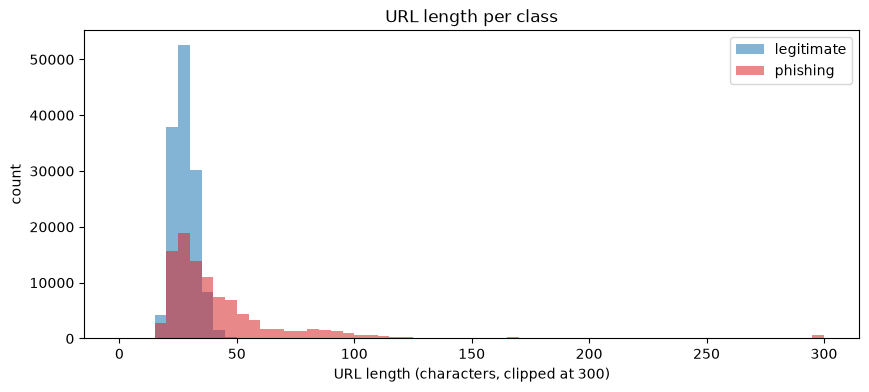

In [8]:
df["length"] = df["url"].str.len()
display(df.groupby("cls")["length"].describe().round(1))
fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, 301, 5)
for cls, color in [("legitimate", "tab:blue"), ("phishing", "tab:red")]:
    ax.hist(df[df.cls == cls]["length"].clip(upper=300), bins=bins, alpha=0.55, label=cls, color=color)
ax.set_xlabel("URL length (characters, clipped at 300)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("URL length per class"); plt.show()

## 7. Random examples
10 random URLs per class (text only, never opened). Useful for a sanity check that labels look plausible.

In [9]:
for cls in ["phishing", "legitimate"]:
    print(f"--- {cls} ---")
    for u in df[df.cls == cls]["url"].sample(10, random_state=42):
        print(u)
    print()

--- phishing ---
http://www.soeme.com
http://www.v2cde1b0d66c767a23cfb34c14552836d3.ws
https://locateme.co.nz/wp-content/jam/ichiemagiksouthwest123.html
http://www.kwan078lj.web.app
https://jumptruegallery.000webhostapp.com/download-documents
https://www.jcb.dotcombinations.com/
https://www.1000bottlesparty.com/jp
http://www.artzvuk.by
https://leszek.arekhasnik.pl/add/email@example.com
https://193-42-33-145.cprapid.com/

--- legitimate ---
https://www.atelierozmoz.be
https://www.diemon.com
https://www.wausauschools.org
https://www.paademode.com
https://www.boxturtles.com
https://www.mmstadium.com
https://www.brswimwear.com
https://www.leathercouncil.org
https://www.historync.org
https://www.toshin.com



## 8. Collection artifacts
Per class, the share of raw URLs that start with `www.` (after the scheme), end with `/`, contain a digit, and contain a hyphen.

These are **collection artifacts**, not properties of phishing itself. The legitimate URLs look like a list of site homepages that was collected in one uniform way: always `https://www.<site>` with no trailing slash, no path and no query. The phishing URLs were harvested from reports and feeds, so they keep whatever form the attacker used (`http`, no `www.`, trailing slash, paths, tracking IDs, random digits). A model trained on full URLs could reach a high score just by detecting "starts with `www.`" or "has a path", which would say nothing about whether an unseen real-world URL is phishing, because real legitimate URLs have paths, queries and no `www.`.

Version 1 therefore uses the **hostname only**: scheme, `www.`, path, query, fragment, port and credentials are stripped, so those shortcuts are removed. Digits and hyphens in the hostname can still carry real signal and are kept as candidates for later feature work. Preparing the split is done by `src/prepare_data.py`.

In [10]:
no_scheme = df["url"].str.replace(r"^[A-Za-z][A-Za-z0-9+.-]*://", "", regex=True).str.lower()
art = pd.DataFrame({
    "% starting with www.": no_scheme.str.startswith("www."),
    "% ending with /": df["url"].str.endswith("/"),
    "% containing digits": df["url"].str.contains(r"\d"),
    "% containing hyphens": df["url"].str.contains("-", regex=False),
}).groupby(df["cls"]).mean().mul(100).round(1)
art

,% starting with www.,% ending with /,% containing digits,% containing hyphens
cls,,,,
legitimate,100.0,0.0,2.6,7.5
phishing,41.4,36.5,47.6,36.2
